# E-commerce Customer Churn Prediction

This notebook focuses on predicting customer churn for an e-commerce company. We will perform data loading, exploratory data analysis, data preprocessing (handling missing values, feature engineering), model training, and evaluation.

### Importing Libraries
This section imports all the necessary Python libraries required for data manipulation, visualization, and machine learning tasks.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

## Data Loading and Initial Exploration
This section focuses on loading the dataset and performing initial checks to understand its structure, identify missing values, and get basic statistics.

### Dataset Overview
We load the dataset and display the first few rows to get a glimpse of the data. `pd.set_option('display.max_columns', None)` is used to ensure all columns are visible when displaying the DataFrame.

In [84]:
pd.set_option('display.max_columns',None)
df = pd.read_csv('E Commerce Dataset.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


### Descriptive Statistics
This provides a statistical summary of the numerical columns in the dataset, which helps in understanding the distribution and central tendencies of the data. The `.info()` method on the `.describe()` output shows the data types and non-null counts of the statistical summary itself.

In [85]:
df.describe().info()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, count to max
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   8 non-null      float64
 1   Churn                        8 non-null      float64
 2   Tenure                       8 non-null      float64
 3   CityTier                     8 non-null      float64
 4   WarehouseToHome              8 non-null      float64
 5   HourSpendOnApp               8 non-null      float64
 6   NumberOfDeviceRegistered     8 non-null      float64
 7   SatisfactionScore            8 non-null      float64
 8   NumberOfAddress              8 non-null      float64
 9   Complain                     8 non-null      float64
 10  OrderAmountHikeFromlastYear  8 non-null      float64
 11  CouponUsed                   8 non-null      float64
 12  OrderCount                   8 non-null      float64
 13  DaySinceLastOrder      

The `.describe()` method directly shows the descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns.

In [86]:

df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


### Data Information
The `.info()` method provides a concise summary of the DataFrame, including the number of entries, number of columns, data types of each column, non-null values, and memory usage. This is crucial for identifying missing data and incorrect data types.

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Missing Values
We check for the presence of null (missing) values in each column and sum them up to get a clear picture of how many entries are missing for each feature.

In [88]:

df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


### Duplicate Rows
We check for any duplicate rows in the dataset, which can indicate data entry errors or redundancy. In this case, there are no duplicates.

In [89]:

df.duplicated().sum()

np.int64(0)

### Unique Values
The `.nunique()` method shows the number of unique values in each column, which is helpful for understanding the cardinality of categorical features and identifying potential issues like columns with too many or too few unique values.

In [90]:

df.nunique()

,0
CustomerID,5630
Churn,2
Tenure,36
PreferredLoginDevice,3
CityTier,3
WarehouseToHome,34
PreferredPaymentMode,7
Gender,2
HourSpendOnApp,6
NumberOfDeviceRegistered,6


### Feature Engineering: Dropping `CustomerID`
The `CustomerID` column is a unique identifier for each customer and does not contain predictive information for churn. Therefore, it's dropped from the dataset to avoid overfitting and unnecessary complexity.

In [91]:
df.drop(columns="CustomerID", inplace=True)

### Standardizing Column Names
All column names are converted to lowercase for consistency and easier access throughout the analysis.

In [92]:

#check column names
df.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [93]:

# Change column names to lowercase
df.columns = [col.lower() for col in df.columns]
df.columns

Index(['churn', 'tenure', 'preferredlogindevice', 'citytier',
       'warehousetohome', 'preferredpaymentmode', 'gender', 'hourspendonapp',
       'numberofdeviceregistered', 'preferedordercat', 'satisfactionscore',
       'maritalstatus', 'numberofaddress', 'complain',
       'orderamounthikefromlastyear', 'couponused', 'ordercount',
       'daysincelastorder', 'cashbackamount'],
      dtype='object')

## Exploratory Data Analysis (EDA)
This section involves visualizing the distribution of features and their relationship with the target variable (`churn`). Features are categorized into those suitable for count plots (fewer unique values) and histograms (more unique values).

### Categorizing Features for Visualization
Columns are divided into `count_col` (for categorical/low cardinality features) and `hist_col` (for numerical/high cardinality features) based on the number of unique values. This helps in choosing appropriate visualization techniques.

In [94]:
# segment the columns of the DataFrame into two lists based on the number of unique values each column contains.
count_col = []
hist_col = []
for column in df.columns:
    unique_value = df[column].nunique()
    if unique_value <= 20:
        count_col.append(column)
    else:
        hist_col.append(column)

### Count Plots for Categorical Features
This visualizes the distribution of each categorical feature using count plots. Each subplot shows the frequency of different categories within a feature.

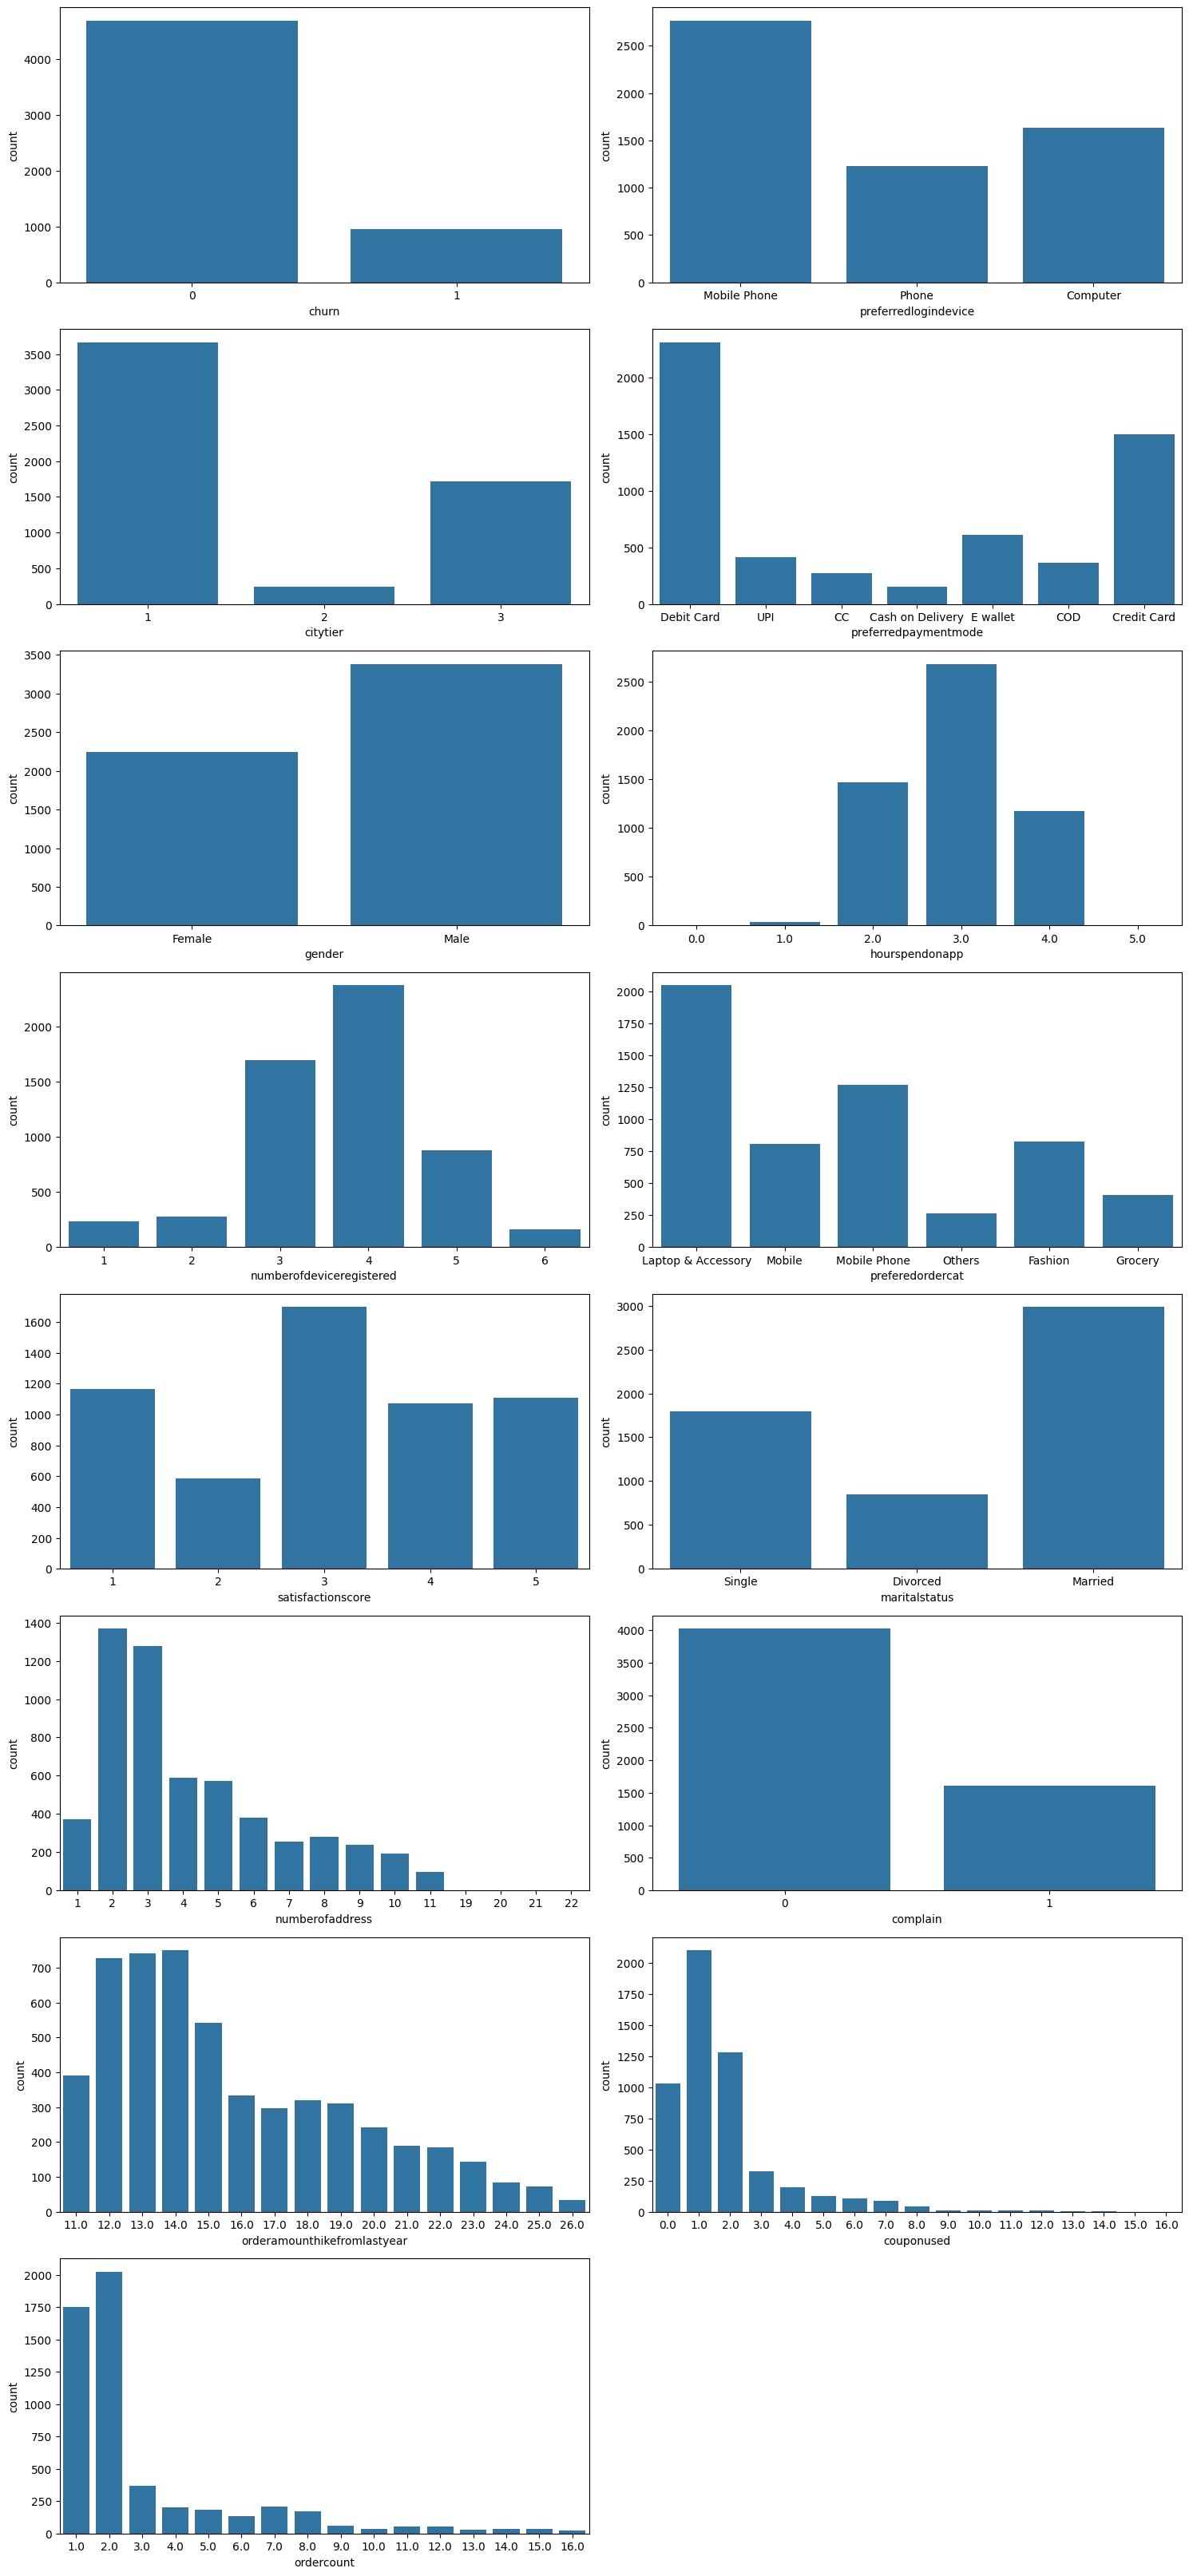

In [95]:
plt.figure(figsize=(15,40))
plot_num = 1
for col in count_col:
    plt.subplot(10,2,plot_num)
    sns.countplot(data=df, x=col)
    plot_num += 1
    plt.tight_layout()

### Histograms for Numerical Features
This visualizes the distribution of each numerical feature using histograms, providing insights into their range, central tendency, and spread.

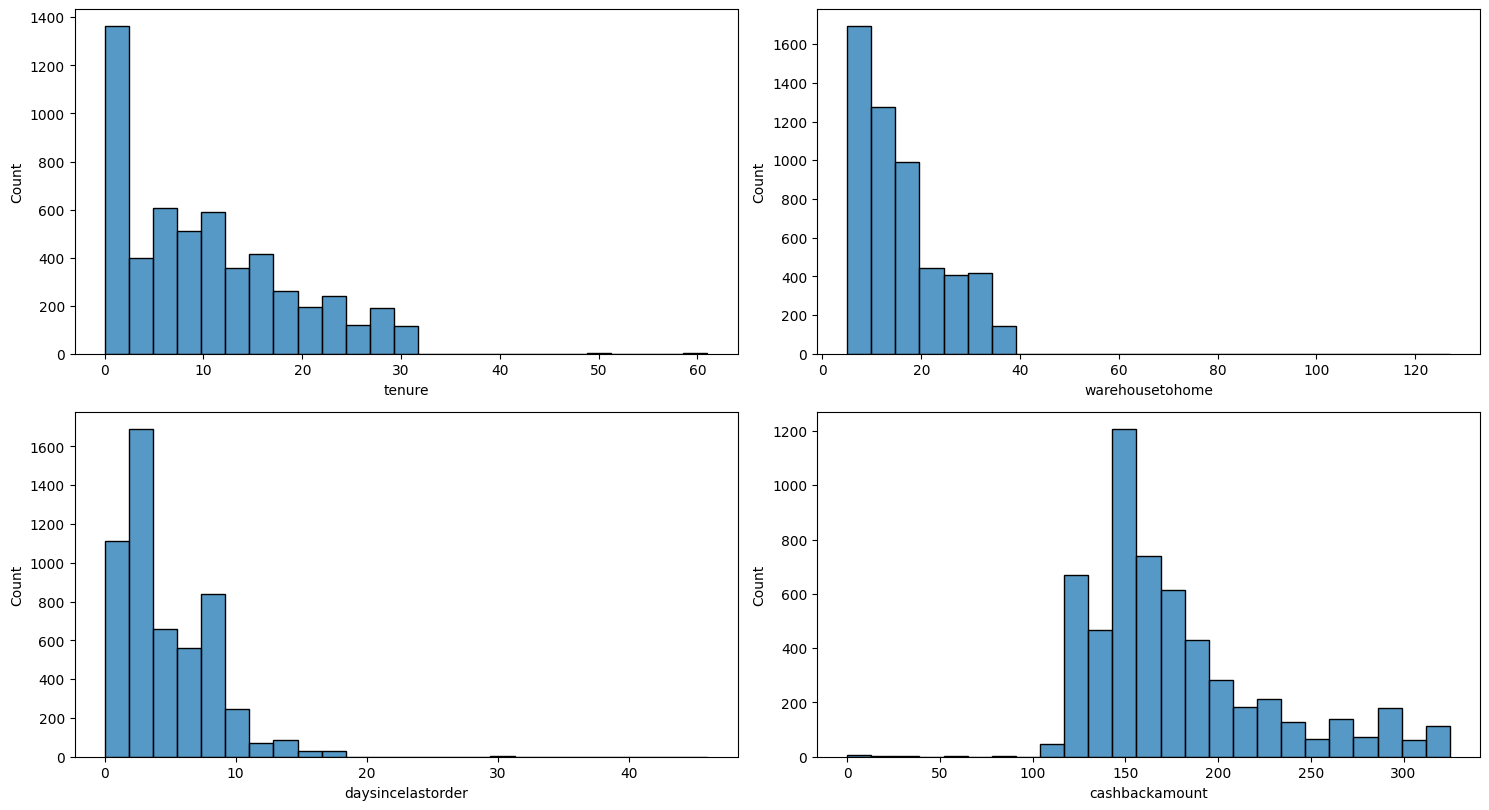

In [96]:

plt.figure(figsize=(15,40))
plot_num = 1
for col in hist_col:
    plt.subplot(10,2,plot_num)
    sns.histplot(data=df, x=col,bins=25)
    plot_num += 1
    plt.tight_layout()

### Churn Analysis by Categorical Features
These count plots show the distribution of churn (`churn` = 0 for no churn, 1 for churn) across different categories of selected features. This helps identify which categorical factors might be influencing customer churn.

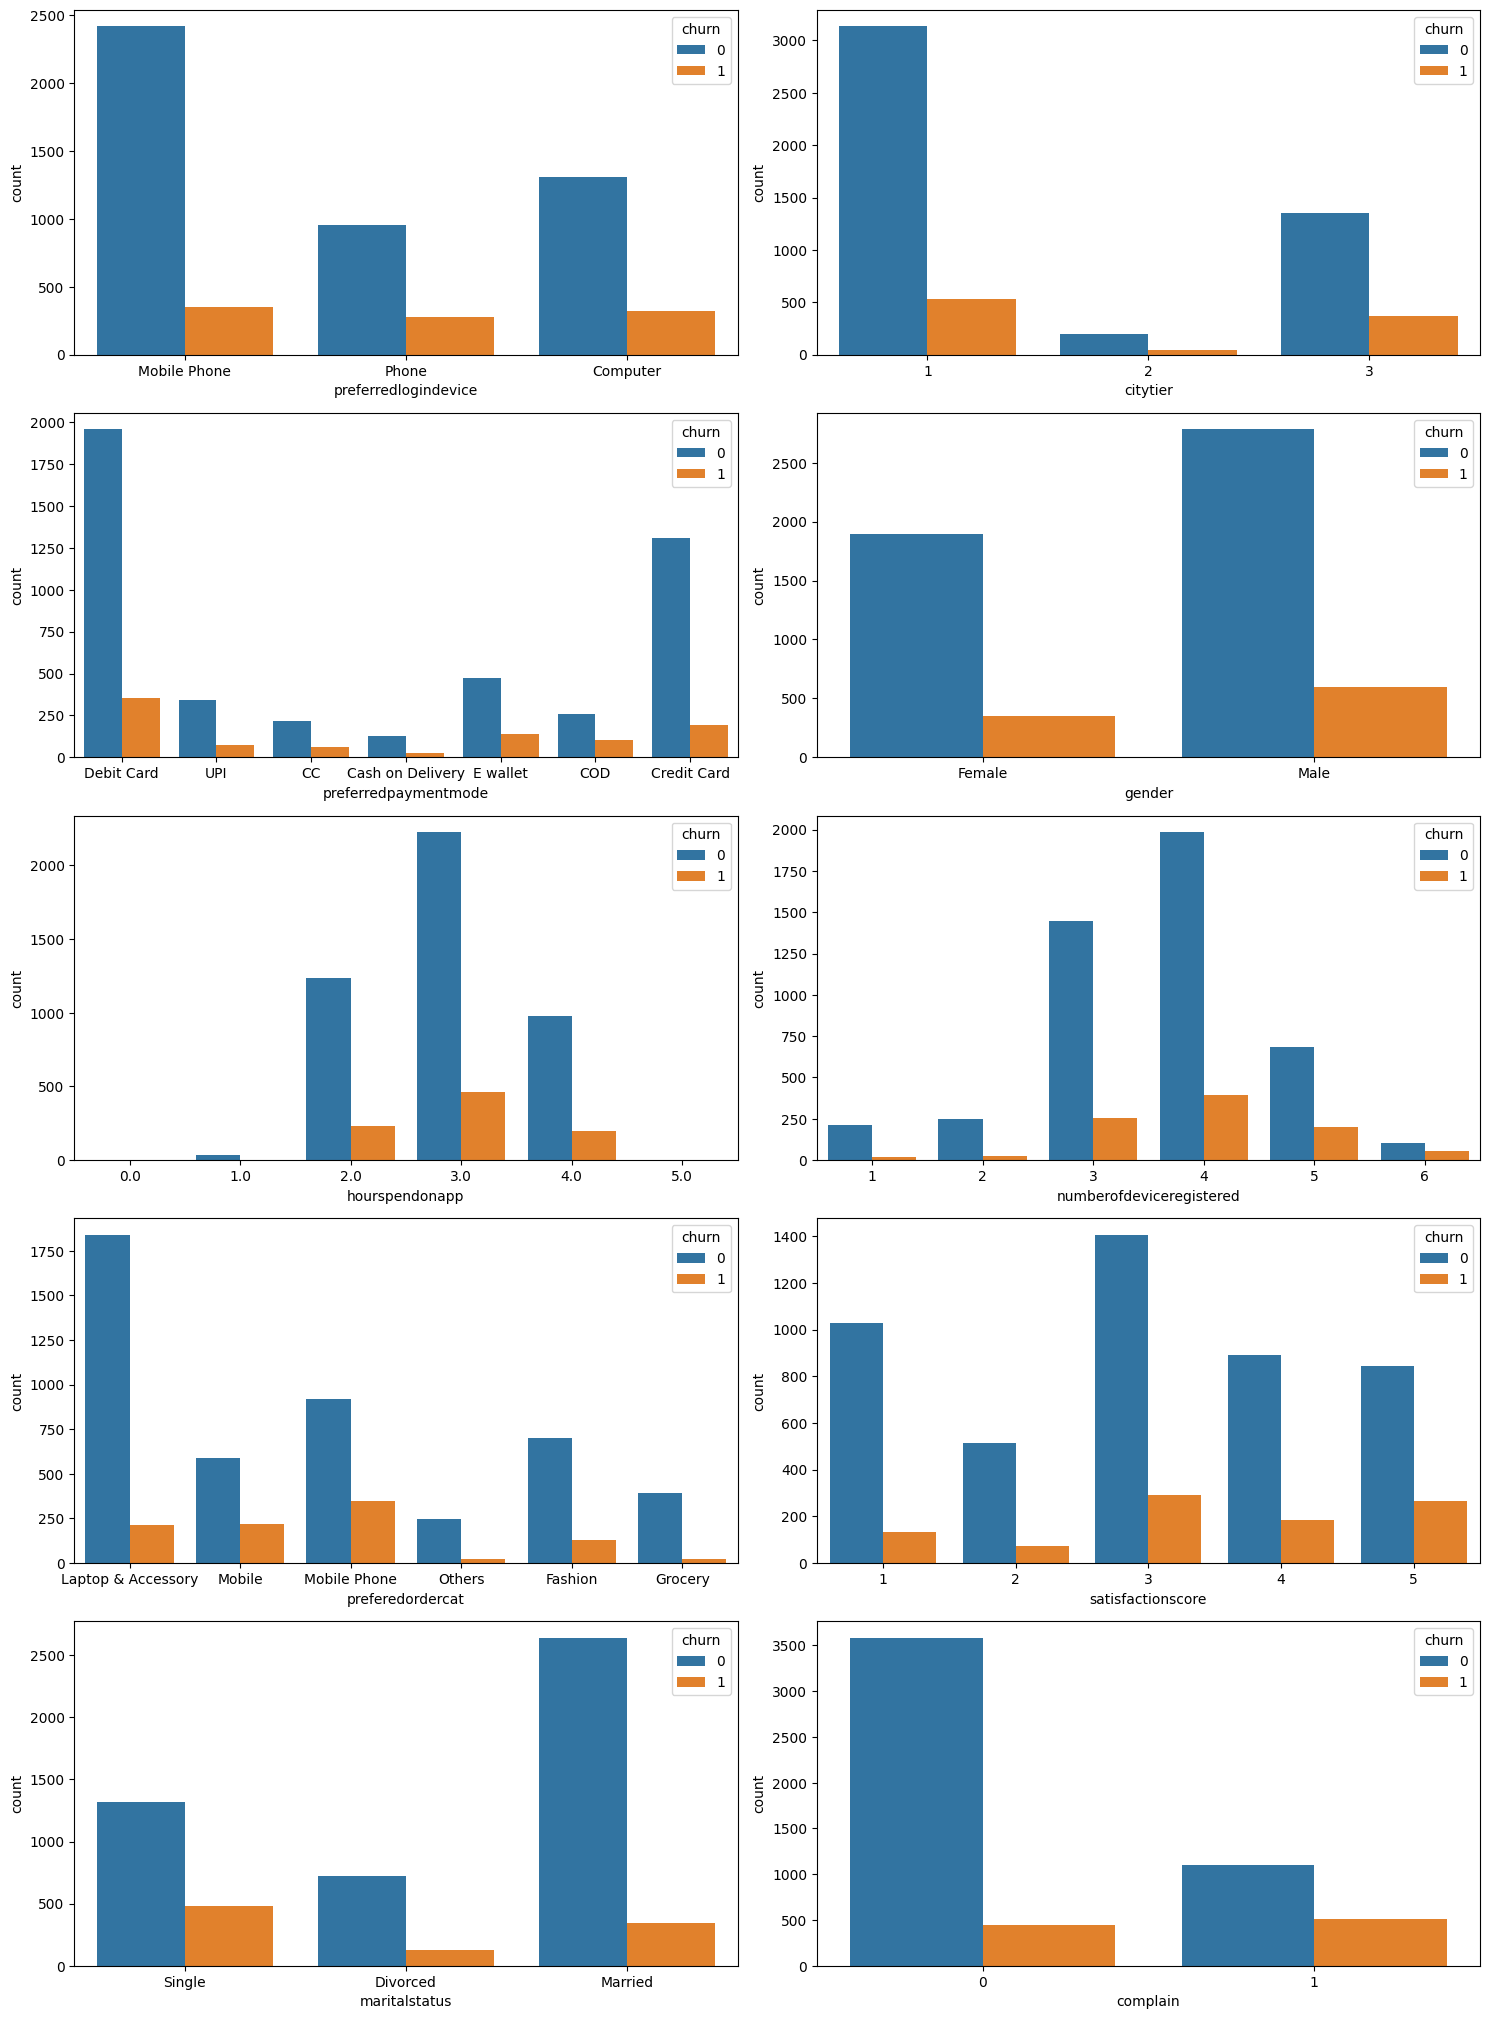

In [97]:
plt.figure(figsize=(15,40))
plot_num = 1
for col in count_col:
    if df[col].nunique() <= 8 and col != "churn":
        plt.subplot(10,2,plot_num)
        sns.countplot(data=df, x=col, hue="churn")
        plot_num += 1
        plt.tight_layout()

## Data Preprocessing for Machine Learning
This section prepares the data for machine learning models, including handling missing values, encoding categorical variables, and splitting the data into training and testing sets.

In [98]:
from sklearn.impute import SimpleImputer  # Imports SimpleImputer for handling missing data with basic strategies.
from sklearn.experimental import enable_iterative_imputer  # Enables the experimental IterativeImputer in scikit-learn.
from sklearn.impute import IterativeImputer  # Imports IterativeImputer for advanced imputation techniques using iterative models.
from sklearn.ensemble import RandomForestRegressor  # Imports RandomForestRegressor for regression tasks using ensemble methods.
import pandas as pd  # Imports the pandas library for data manipulation and analysis.

def fill_missing_values(df, random_state=None):
    # Step 1: Identify numeric and categorical columns
    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

    # Step 2: Impute numeric columns with the mean
    numeric_imputer = SimpleImputer(strategy='mean')
    df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])

    # Step 3: Handle categorical columns using one-hot encoding
    for col in categorical_columns:
        if df[col].dtype == 'object':
            # Convert categorical column to one-hot encoded representation
            encoded_cols = pd.get_dummies(df[col], prefix=col)
            # Concatenate one-hot encoded columns and drop the original categorical column
            df = pd.concat([df.drop(col, axis=1), encoded_cols], axis=1)

    # Step 4: Iterative Imputation for remaining missing values (if any) using RandomForestRegressor
    # This step is performed after one-hot encoding, so all columns are numeric.
    # If there are no more missing values after Step 2, this step will essentially pass through.
    rf_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=random_state))
    df = pd.DataFrame(rf_imputer.fit_transform(df), columns=df.columns)

    return df

# Call the function to fill missing values and encode categorical features
df = fill_missing_values(df, random_state=42)

### Transformed Data Head
Displaying the first few rows of the DataFrame after handling missing values and one-hot encoding categorical features. This confirms the data is now fully numerical and ready for model training.

### Train-Test Split
The dataset is split into features (`X`) and the target variable (`y`, which is 'churn'). Then, `X` and `y` are further divided into training and testing sets to evaluate the model's performance on unseen data. `test_size=0.2` means 20% of the data will be used for testing, and `random_state=0` ensures reproducibility.

In [99]:

df.head()

,churn,tenure,citytier,warehousetohome,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount,preferredlogindevice_Computer,preferredlogindevice_Mobile Phone,preferredlogindevice_Phone,preferredpaymentmode_CC,preferredpaymentmode_COD,preferredpaymentmode_Cash on Delivery,preferredpaymentmode_Credit Card,preferredpaymentmode_Debit Card,preferredpaymentmode_E wallet,preferredpaymentmode_UPI,gender_Female,gender_Male,preferedordercat_Fashion,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others,maritalstatus_Divorced,maritalstatus_Married,maritalstatus_Single
0,1.0,4.000000,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,160.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,10.189899,1.0,8.0,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,121.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,10.189899,1.0,30.0,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.000000,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.000000,1.0,12.0,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,130.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [100]:
from sklearn.model_selection import train_test_split

# Split model into training and test set
X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Handling Imbalanced Data with SMOTE
Customer churn datasets often suffer from class imbalance (fewer churned customers than non-churned). SMOTE (Synthetic Minority Over-sampling Technique) is used to create synthetic samples of the minority class (churned customers) to balance the dataset. This helps prevent the model from being biased towards the majority class.

In [101]:

from imblearn.over_sampling import SMOTE

print('Before upsampling count of label 0 {}'.format(sum(y_train==0)))
print('Before upsampling count of label 1 {}'.format(sum(y_train==1)))
# Minority Over Sampling Technique
sm = SMOTE(sampling_strategy = 1, random_state=1)
X_train_s, y_train_s = sm.fit_resample(X_train, y_train.ravel())

print('After upsampling count of label 0 {}'.format(sum(y_train_s==0)))
print('After upsampling count of label 1 {}'.format(sum(y_train_s==1)))

Before upsampling count of label 0 3743
Before upsampling count of label 1 761
After upsampling count of label 0 3743
After upsampling count of label 1 3743


## Model Training and Evaluation
This section involves importing various machine learning models, training them on the preprocessed data, evaluating their performance using cross-validation, and selecting the best model.

In [102]:

# Libraries
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

from sklearn.linear_model import LogisticRegressionCV, RidgeClassifierCV, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

### Model Initialization and Metrics Setup
Several classification models, including ensemble methods, linear models, nearest neighbors, and XGBoost, are initialized. Lists are prepared to store evaluation metrics for each model.

In [103]:
#Initialize the models
models=[
    #Ensemble
    AdaBoostClassifier(),
    BaggingClassifier(),
    GradientBoostingClassifier(),
    RandomForestClassifier(),

    #Linear Models
    LogisticRegressionCV(),
    RidgeClassifierCV(),

    #Nearest Neighbour
    KNeighborsClassifier(),

    #XGBoost
    XGBClassifier()
]

metrics_cols = ['model_name','test_accuracy','test_precision','test_recall','test_f1']

model_name=[]
test_acuracy=[]
test_precision=[]
test_recall=[]
test_f1=[]

### Cross-Validation for Model Comparison
Each initialized model is evaluated using 5-fold cross-validation. This technique assesses the model's generalization ability by splitting the data into five parts, training on four, and testing on one, rotating through all possible test sets. Accuracy, precision, recall, and F1-score are calculated for each model. The results are then compiled into a DataFrame and styled for easy comparison.

In [104]:

# Model Evaluation

scoring = ['accuracy','precision', 'recall', 'f1']

for model in models:
    cv_results = model_selection.cross_validate(model, X, y, cv=5,
                                                scoring=scoring, return_train_score=True)
    model_name.append(model.__class__.__name__)
    test_acuracy.append(round(cv_results['test_accuracy'].mean(),3)*100)
    test_precision.append(round(cv_results['test_precision'].mean(),3)*100)
    test_recall.append(round(cv_results['test_recall'].mean(),3)*100)
    test_f1.append(round(cv_results['test_f1'].mean(),3)*100)

metrics_data = [model_name, test_acuracy, test_precision, test_recall, test_f1]
m = {n:m for n,m in zip(metrics_cols,metrics_data)}
model_metrics = pd.DataFrame(m)
model_metrics = model_metrics.sort_values('test_accuracy', ascending=False)
metrics_styled = model_metrics.style.background_gradient(subset=['test_accuracy', 'test_f1'], cmap='summer')
metrics_styled

,model_name,test_accuracy,test_precision,test_recall,test_f1
7,XGBClassifier,99.300000,98.200000,97.700000,97.900000
3,RandomForestClassifier,98.300000,99.000000,90.700000,94.600000
1,BaggingClassifier,97.900000,97.500000,90.000000,93.600000
2,GradientBoostingClassifier,92.000000,84.900000,63.700000,72.700000
4,LogisticRegressionCV,89.400000,77.800000,51.800000,62.100000
0,AdaBoostClassifier,89.100000,73.600000,54.800000,62.600000
5,RidgeClassifierCV,87.400000,86.200000,29.700000,44.200000
6,KNeighborsClassifier,87.300000,69.300000,44.100000,53.900000


### Initial Final Model Training (RandomForestClassifier)
Here, a RandomForestClassifier is trained on the entire training set, and its accuracy is evaluated on the test set. This serves as an initial benchmark.

In [105]:

final_model=RandomForestClassifier()
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

final_model.score(X_test, y_test)

0.9591474245115453

### Final Model Training (XGBClassifier)
An XGBoost Classifier, which showed strong performance in the cross-validation, is trained on the full training data. Its accuracy on the test set is then printed.

In [106]:

final_model=XGBClassifier()
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

final_model.score(X_test, y_test)

0.9769094138543517

### Feature Importance (Gain)
This section visualizes feature importance based on the 'gain' metric from the XGBoost model. 'Gain' indicates the average gain across all splits the feature is used in. Higher gain means the feature is more important for predicting the target.

Feature Importance Gain


<Axes: >

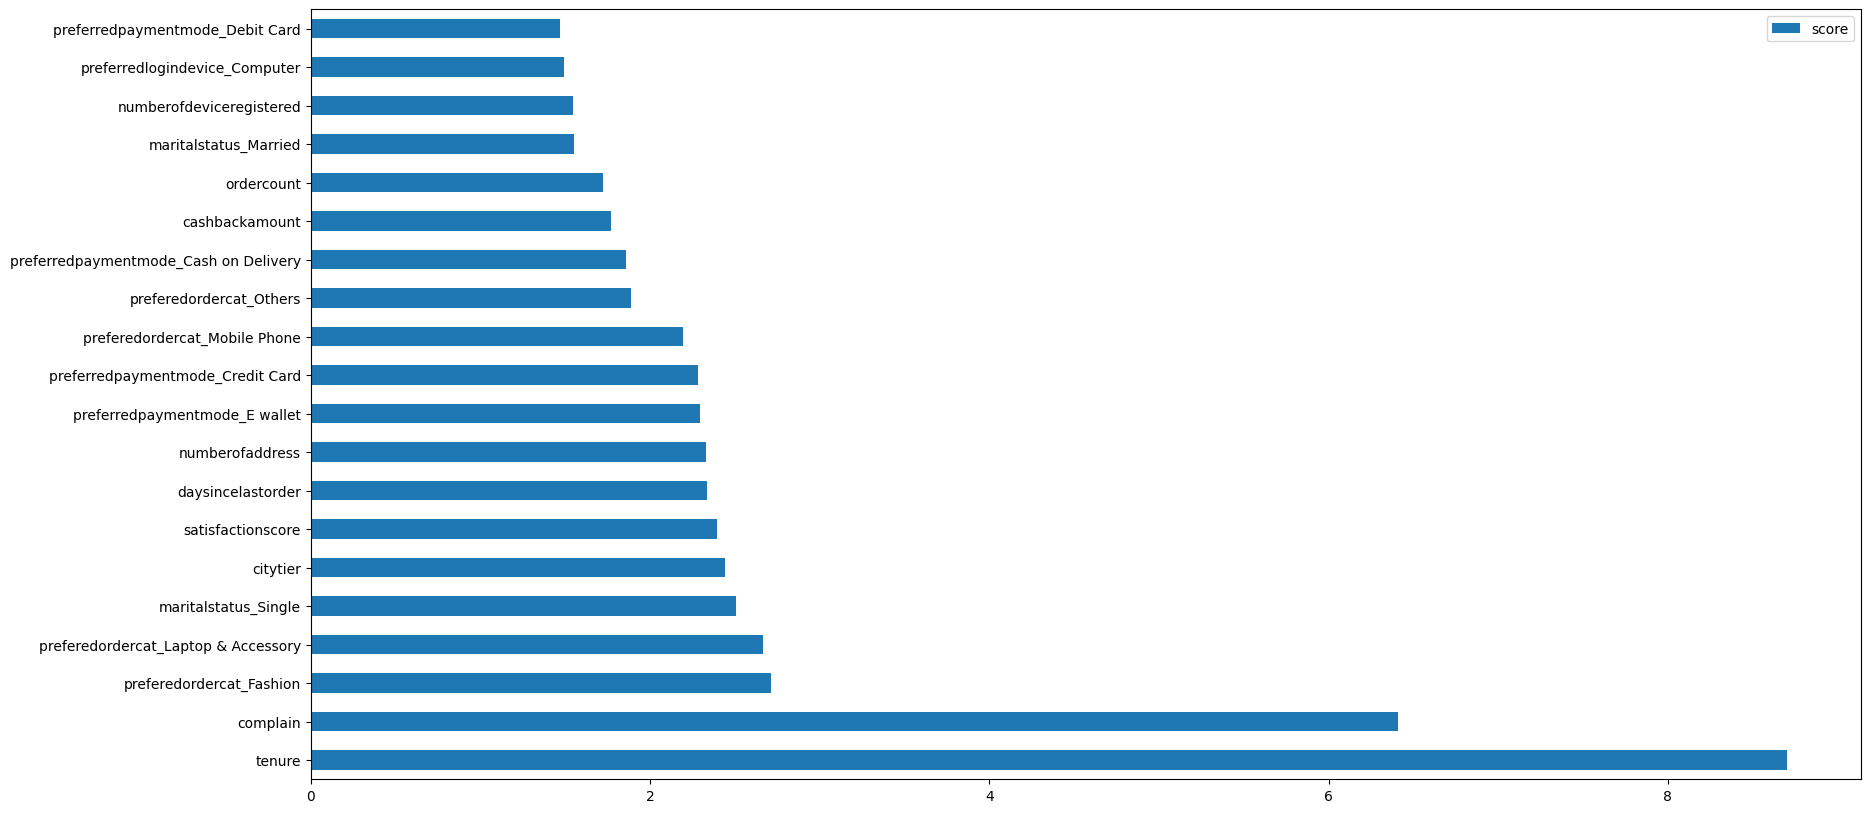

In [107]:
print("Feature Importance Gain")
feature_important = final_model.get_booster().get_score(importance_type="gain")
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh', figsize = (20,10)) ## plot top 40 features

### Feature Importance (Weight)
This visualizes feature importance based on the 'weight' metric from the XGBoost model. 'Weight' refers to the number of times a feature appears in the ensemble of trees. This also helps in understanding which features the model relies on most frequently.

Feature Importance Weight


<Axes: >

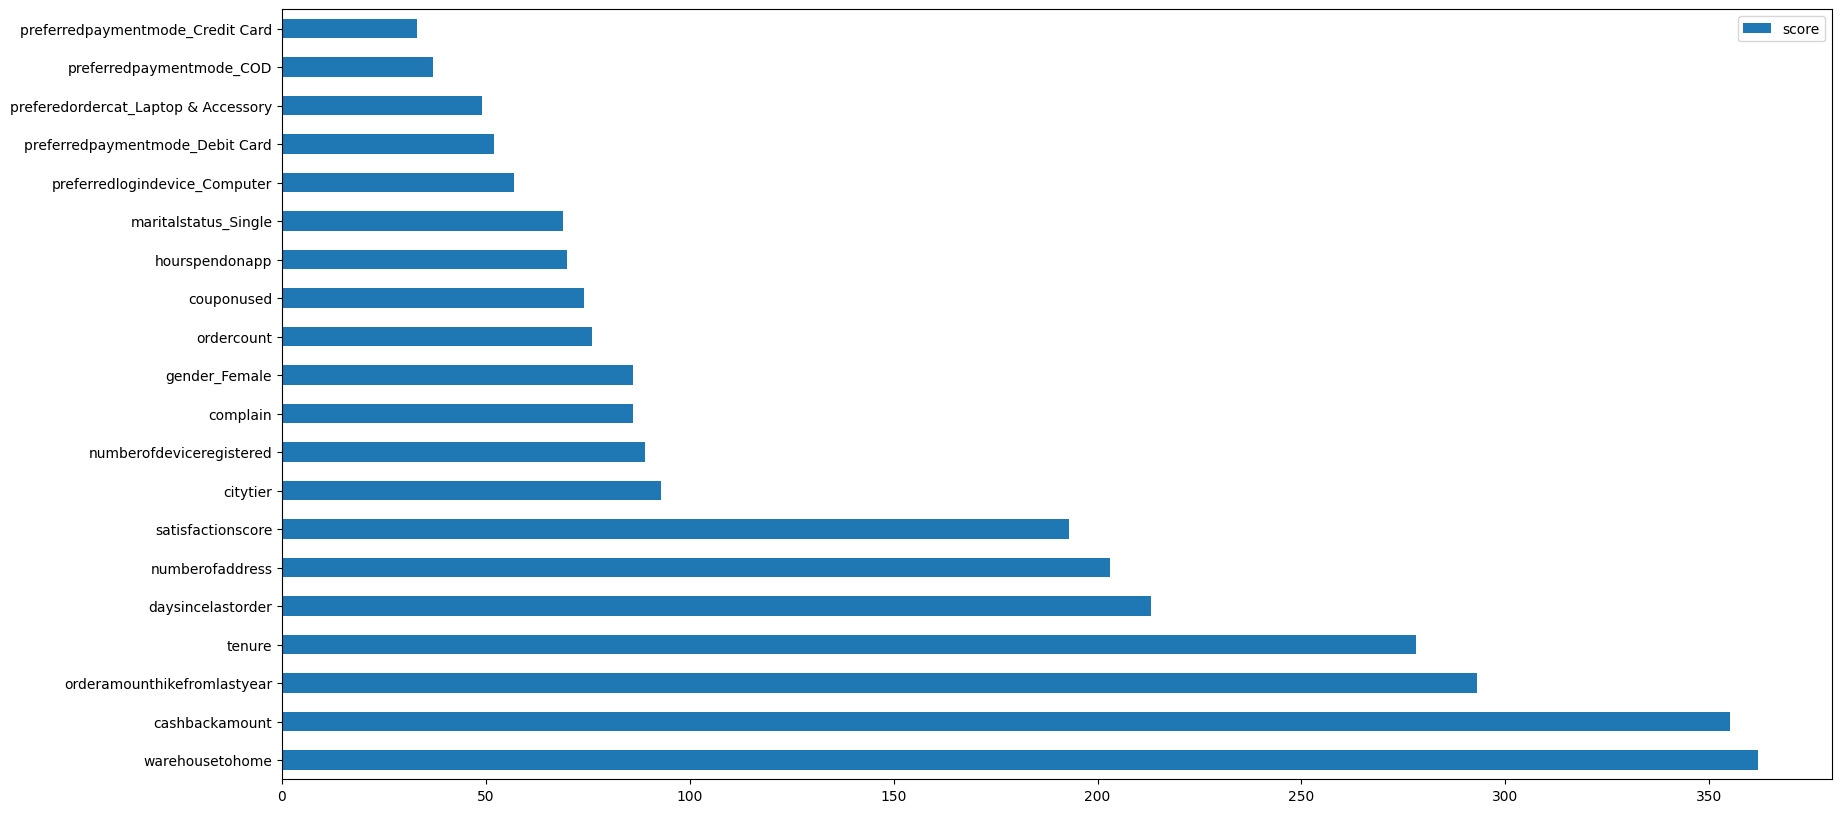

In [108]:

print("Feature Importance Weight")
feature_important = final_model.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh', figsize = (20,10)) ## plot top 40 features

### Feature Selection: Dropping Low-Importance Features
Based on the feature importance analysis, several one-hot encoded categorical features (related to preferred login device, payment mode, and order category) were identified as having low importance. These columns are dropped from the dataset to simplify the model and potentially improve performance by removing noise.

In [109]:
#select the columns
cols_to_drop = ['preferredlogindevice_Computer', 'preferredlogindevice_Mobile Phone', 'preferredlogindevice_Phone',
                'preferredpaymentmode_CC', 'preferredpaymentmode_COD', 'preferredpaymentmode_Cash on Delivery', 'preferredpaymentmode_Credit Card',
                'preferredpaymentmode_Debit Card', 'preferredpaymentmode_E wallet', 'preferredpaymentmode_UPI', 'preferedordercat_Fashion',
                'preferedordercat_Grocery', 'preferedordercat_Laptop & Accessory', 'preferedordercat_Mobile', 'preferedordercat_Mobile Phone', 'preferedordercat_Others' ]
X.drop(cols_to_drop, axis = 1, inplace = True)

The same low-importance columns are also dropped from the training and testing sets to ensure consistency before retraining the model.

In [110]:
X_train.drop(cols_to_drop, axis = 1, inplace = True)
X_test.drop(cols_to_drop, axis = 1, inplace = True)

### Data Head After Feature Selection
Displaying the first few rows of the feature set `X` after removing the low-importance features. This confirms the new structure of the data used for the final model.

In [111]:
X.head()

,tenure,citytier,warehousetohome,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount,gender_Female,gender_Male,maritalstatus_Divorced,maritalstatus_Married,maritalstatus_Single
0,4.000000,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,160.0,1.0,0.0,0.0,0.0,1.0
1,10.189899,1.0,8.0,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,121.0,0.0,1.0,0.0,0.0,1.0
2,10.189899,1.0,30.0,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.0,0.0,1.0,0.0,0.0,1.0
3,0.000000,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.0,0.0,1.0,0.0,0.0,1.0
4,0.000000,1.0,12.0,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,130.0,0.0,1.0,0.0,0.0,1.0


### Converting to NumPy Arrays
Machine learning models, especially some from libraries like XGBoost, often perform better or require input data as NumPy arrays. This step converts the pandas DataFrames `X_train` and `X_test` into NumPy arrays.

In [112]:
X_test = X_test.values
X_train = X_train.values

### Retraining and Evaluating the Final XGBoost Model
The XGBoost Classifier is retrained with the feature-selected dataset, and its accuracy is calculated on the `X_test` set. This is the final evaluation of the model after optimizing features.

In [113]:
# Run the model
final_model=XGBClassifier()
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

final_model.score(X_test, y_test)

0.9733570159857904

### Confusion Matrix
A confusion matrix is plotted to visualize the performance of the final XGBoost model. It shows the number of true positive, true negative, false positive, and false negative predictions, which are essential for understanding classification performance beyond simple accuracy, especially in imbalanced datasets.

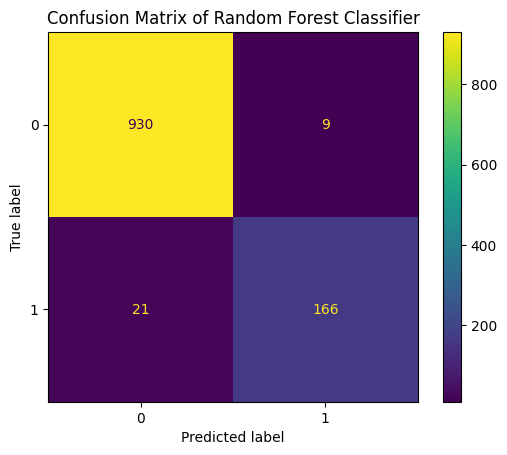

In [114]:

# Confusion Matrix
cm = confusion_matrix(y_test, test_pred, labels=final_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot()
plt.title('Confusion Matrix of Random Forest Classifier')
plt.show()

### Sample Predictions
This code block generates predictions on the test set and displays a sample of the actual vs. predicted churn values. This provides a direct comparison of the model's output against the ground truth.

In [115]:

# Make predictions on the test set
y_pred = final_model.predict(X_test)

# Create a list to store the actual and predicted values
results = []

# Store the actual and predicted log_price values in the list
for actual, predicted in zip(y_test, y_pred):
    results.append((actual, predicted))

# Convert the list into a DataFrame
XGBoost_df = pd.DataFrame(results, columns=['Actual', 'Predicted'])

# Print the DataFrame
XGBoost_df.tail(10)

,Actual,Predicted
1116,0.0,0
1117,0.0,0
1118,0.0,1
1119,0.0,0
1120,0.0,0
1121,0.0,0
1122,1.0,0
1123,0.0,0
1124,1.0,1
1125,0.0,0


In [116]:
final_model.save_model("customer_churn_model.json")

In [117]:
import json

with open("columns.json", "w") as f:
    json.dump(X.columns.tolist(), f)

In [118]:
from google.colab import files

files.download("customer_churn_model.json")
files.download("columns.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>